In [3]:
import idx2numpy
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt

In [4]:
# --- Cargar imágenes y etiquetas desde archivos locales ---
images = idx2numpy.convert_from_file("train-images-idx3-ubyte")
labels = idx2numpy.convert_from_file("train-labels-idx1-ubyte")

# Normalizar y convertir a tensores
X = torch.tensor(images / 255.0, dtype=torch.float32).unsqueeze(1)  # (N,1,28,28)
y = torch.tensor(labels, dtype=torch.long)

# Dataset completo
dataset = TensorDataset(X, y)

# Dividir en train y val (80/20 por ejemplo)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# DataLoaders
dataloader = {
    'train': DataLoader(train_dataset, batch_size=32, shuffle=True),
    'val': DataLoader(val_dataset, batch_size=1000, shuffle=False)
}

In [5]:

def build_model(D_in=28*28, H=128, D_out=10):
    return torch.nn.Sequential(
        torch.nn.Flatten(),              # aplanar imagen 28x28 -> 784
        torch.nn.Linear(D_in, H),
        torch.nn.ReLU(),
        torch.nn.Linear(H, H),
        torch.nn.ReLU(),
        torch.nn.Linear(H, D_out)        # 10 clases
    )

In [6]:
def fit(model, dataloader, epochs=200, log_each=10, weight_decay=1e-4, early_stopping=20):
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=weight_decay)

    l, acc = [], []
    val_l, val_acc = [], []
    best_acc, step = 0, 0

    for e in range(1, epochs+1):
        # --- entrenamiento ---
        _l, _acc = [], []
        model.train()
        for x_b, y_b in dataloader['train']:
            y_pred = model(x_b)
            loss = criterion(y_pred, y_b)
            _l.append(loss.item())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            y_probas = torch.argmax(y_pred, axis=1)
            _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().numpy()))

        l.append(np.mean(_l))
        acc.append(np.mean(_acc))

        # --- validación ---
        model.eval()
        _l, all_true, all_pred = [], [], []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                y_pred = model(x_b)
                loss = criterion(y_pred, y_b)
                _l.append(loss.item())

                preds = torch.argmax(y_pred, axis=1)
                all_true.extend(y_b.cpu().numpy())
                all_pred.extend(preds.cpu().numpy())

        val_l.append(np.mean(_l))

        # métricas de clasificación
        acc_v = accuracy_score(all_true, all_pred)
        prec_v = precision_score(all_true, all_pred, average='weighted')
        rec_v  = recall_score(all_true, all_pred, average='weighted')
        f1_v   = f1_score(all_true, all_pred, average='weighted')

        val_acc.append(acc_v)

        # guardar mejor modelo
        if acc_v > best_acc:
            best_acc = acc_v
            torch.save(model.state_dict(), 'ckpt.pt')
            step = 0
            print(f"Mejor modelo guardado con acc {best_acc:.5f} en epoch {e}")
        else:
            step += 1

        # early stopping
        if early_stopping and step > early_stopping:
            print(f"Entrenamiento detenido en epoch {e} por no mejorar en {early_stopping} epochs seguidas")
            break

        # log
        if not e % log_each:
            print(f"Epoch {e}/{epochs} "
                  f"loss {l[-1]:.5f} acc {acc[-1]:.5f} | "
                  f"val_loss {val_l[-1]:.5f} val_acc {acc_v:.5f} | "
                  f"prec {prec_v:.5f} rec {rec_v:.5f} f1 {f1_v:.5f}")

    # cargar mejor modelo
    model.load_state_dict(torch.load('ckpt.pt'))

    # reporte final por clase
    print("\n=== Reporte de Clasificación Final ===")
    print(classification_report(all_true, all_pred))

    return {
        'epoch': list(range(1, len(l)+1)),
        'loss': l, 'acc': acc,
        'val_loss': val_l, 'val_acc': val_acc
    }

In [7]:
# --- Entrenamiento ---
model = build_model()
hist = fit(model, dataloader)

Mejor modelo guardado con acc 0.84683 en epoch 1
Mejor modelo guardado con acc 0.86292 en epoch 2
Mejor modelo guardado con acc 0.86742 en epoch 3
Mejor modelo guardado con acc 0.88142 en epoch 5
Mejor modelo guardado con acc 0.88158 en epoch 9
Mejor modelo guardado con acc 0.88717 en epoch 10
Epoch 10/200 loss 0.25944 acc 0.90187 | val_loss 0.31079 val_acc 0.88717 | prec 0.88917 rec 0.88717 f1 0.88760
Mejor modelo guardado con acc 0.88975 en epoch 12
Mejor modelo guardado con acc 0.89000 en epoch 15
Epoch 20/200 loss 0.21139 acc 0.91965 | val_loss 0.33062 val_acc 0.88900 | prec 0.88973 rec 0.88900 f1 0.88896
Mejor modelo guardado con acc 0.89100 en epoch 24
Mejor modelo guardado con acc 0.89217 en epoch 25
Mejor modelo guardado con acc 0.89225 en epoch 28
Epoch 30/200 loss 0.18348 acc 0.92946 | val_loss 0.34432 val_acc 0.88992 | prec 0.88839 rec 0.88992 f1 0.88821
Epoch 40/200 loss 0.16592 acc 0.93706 | val_loss 0.34271 val_acc 0.88675 | prec 0.88641 rec 0.88675 f1 0.88599
Mejor model

In [8]:
# Cargar imágenes y etiquetas de test
test_images = idx2numpy.convert_from_file("t10k-images-idx3-ubyte")
test_labels = idx2numpy.convert_from_file("t10k-labels-idx1-ubyte")

# Normalizar y convertir a tensores
X_test = torch.tensor(test_images / 255.0, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(test_labels, dtype=torch.long)

# Dataset y DataLoader
test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

In [9]:
from sklearn.metrics import classification_report, confusion_matrix

# Evaluación
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for x_b, y_b in test_loader:
        outputs = model(x_b)
        preds = torch.argmax(outputs, dim=1)
        y_true.extend(y_b.numpy())
        y_pred.extend(preds.numpy())

# Métricas
print("Reporte de clasificación en test:")
print(classification_report(y_true, y_pred))

print("Matriz de confusión:")
print(confusion_matrix(y_true, y_pred))


Reporte de clasificación en test:
              precision    recall  f1-score   support

           0       0.85      0.82      0.83      1000
           1       0.98      0.97      0.98      1000
           2       0.75      0.86      0.80      1000
           3       0.84      0.92      0.88      1000
           4       0.83      0.81      0.82      1000
           5       0.94      0.97      0.96      1000
           6       0.78      0.65      0.71      1000
           7       0.96      0.94      0.95      1000
           8       0.99      0.95      0.97      1000
           9       0.96      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

Matriz de confusión:
[[820   5  25  60   5   1  80   0   4   0]
 [  1 974   2  18   4   0   0   0   1   0]
 [ 12   2 865  11  63   1  45   0   1   0]
 [ 16   7  15 924  25   1  10   0   2   0]
 [  1   0 119 

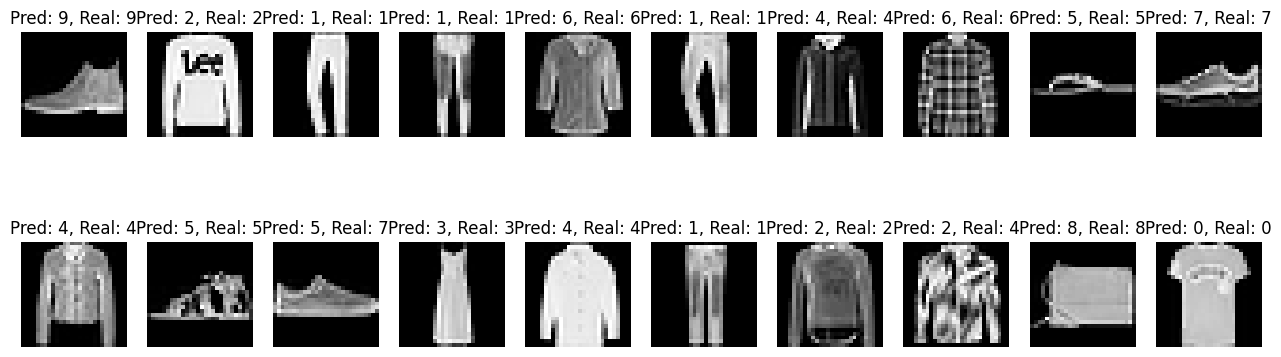

In [13]:
fig, axes = plt.subplots(2, 10, figsize=(16, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].squeeze(), cmap="gray")
    ax.set_title(f"Pred: {y_pred[i]}, Real: {y_true[i]}")
    ax.axis("off")
plt.show()
